# Previsão de Recompra — Modelo Supervisionado sobre RFM

## 1. Objetivo

Prever **quais clientes vão comprar novamente nos próximos 90 dias**, a partir do
comportamento de compra anterior.

Diferente da segmentação (que descreve o presente), este é um problema **supervisionado**:
existe uma resposta certa, conhecida para o passado, e o modelo aprende a antecipá-la.

| | Segmentação RFM | Modelo supervisionado |
|---|---|---|
| Pergunta | Como os clientes se distribuem hoje? | Quem vai comprar nos próximos 90 dias? |
| Precisa de alvo | Não | **Sim** |
| Saída | Rótulo descritivo | Probabilidade por cliente |
| Validação | Julgamento de negócio | Métrica contra o que de fato aconteceu |

**O que muda na prática.** A tabela RFM, do jeito que foi construída na análise anterior,
**não serve diretamente** como base para este modelo. Não por falta de features — por um
problema de construção temporal que, se ignorado, produz um modelo com métrica quase
perfeita e utilidade zero. A seção 2 demonstra isso com números antes de qualquer outra
coisa, porque é o erro que define todo o desenho do restante do notebook.

> **ASSUMPTION — base sintética.** A base real não foi disponibilizada. O gerador dá a
> cada cliente um ciclo de recompra próprio, o que cria sinal previsível de verdade (e
> não ruído puro), permitindo que as métricas façam sentido. Substitua
> `gerar_base_sintetica()` por `pd.read_csv(...)` para usar dados reais.

## 2. O vazamento temporal

### O erro

O caminho intuitivo é: já tenho a tabela RFM, só falta o alvo. Defino "vai comprar" como
*comprou nos últimos 90 dias*, treino o modelo e pronto.

O problema é que **`Recency` e o alvo são a mesma informação**. Se o alvo é "comprou
depois da data X" e a `Recency` foi calculada sobre uma janela que inclui o período
depois de X, então `Recency <= 90` é a própria definição do rótulo, reescrita em outra
unidade. O modelo não aprende comportamento: ele lê a resposta.

O sintoma é uma métrica boa demais. E é traiçoeiro porque não gera erro nenhum — o código
roda, a métrica sai excelente, e o modelo só falha quando entra em produção e recebe
dados em que o futuro ainda não aconteceu.

### A demonstração

O bloco abaixo constrói deliberadamente a versão errada e mede o resultado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score,
                             precision_score, f1_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
sns.set_theme(style='whitegrid')

SEED = 42
DIAS_ALVO = 90


def gerar_base_sintetica(n_clientes=3000, seed=SEED):
    """ASSUMPTION: base real nao disponivel — substitua por pd.read_csv(...).

    Cada cliente tem um ciclo de recompra proprio (intervalo) e uma distancia ate a
    ultima compra. Os pedidos sao construidos de tras para frente a partir dela.
    """
    rng = np.random.default_rng(seed)
    fim_janela = pd.Timestamp('2011-12-09')
    linhas, invoice = [], 500000
    for cliente in range(1, n_clientes + 1):
        dias_desde_ultima = int(rng.integers(0, 730))
        n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))
        intervalo = int(rng.integers(10, 120))
        for p in range(n_pedidos):
            offset = dias_desde_ultima + p * intervalo
            if offset > 729:
                break
            invoice += 1
            data = fim_janela - pd.Timedelta(days=offset) + pd.Timedelta(hours=int(rng.integers(8, 19)))
            devolucao = rng.random() < 0.04
            for _ in range(int(rng.integers(1, 6))):
                qtd = -int(rng.integers(1, 5)) if devolucao else int(rng.integers(1, 15))
                preco = round(float(rng.lognormal(mean=2.0, sigma=0.9)), 2)
                linhas.append((cliente, str(invoice), data, qtd, preco))
    df = pd.DataFrame(linhas, columns=['Customer ID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price'])
    df.loc[df.sample(frac=0.018, random_state=1).index, 'Customer ID'] = np.nan
    df.loc[df.sample(frac=0.006, random_state=2).index, 'Price'] = 0.0
    df = pd.concat([df, df.sample(frac=0.01, random_state=3)], ignore_index=True)
    return df.sample(frac=1, random_state=4).reset_index(drop=True)


def preparar_dados(df):
    df = df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price']).copy()
    df = df.drop_duplicates()
    df['Customer ID'] = df['Customer ID'].astype('int64')
    df['LineTotal'] = df['Quantity'] * df['Price']
    df['eh_devolucao'] = df['Quantity'] < 0
    return df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]


raw_df = gerar_base_sintetica()
raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'])
df = preparar_dados(raw_df)

data_corte = df['InvoiceDate'].max().normalize() - pd.Timedelta(days=DIAS_ALVO)
compradores_futuros = set(df.loc[df['InvoiceDate'] > data_corte, 'Customer ID'])

# ---- VERSAO ERRADA: RFM calculado sobre TODA a base, inclusive a janela do alvo ----
ref_vazada = df['InvoiceDate'].max() + pd.Timedelta(days=1)
compras = df[~df['eh_devolucao']]
rfm_vazado = compras.groupby('Customer ID').agg(
    Frequency=('Invoice', 'nunique'),
    UltimaCompra=('InvoiceDate', 'max'),
)
rfm_vazado['Monetary'] = df.groupby('Customer ID')['LineTotal'].sum()
rfm_vazado['Recency'] = (ref_vazada - rfm_vazado['UltimaCompra']).dt.days
rfm_vazado['alvo'] = rfm_vazado.index.isin(compradores_futuros).astype(int)

X_vazado = rfm_vazado[['Recency', 'Frequency', 'Monetary']]
y_vazado = rfm_vazado['alvo']

Xtr, Xte, ytr, yte = train_test_split(X_vazado, y_vazado, test_size=0.3,
                                      random_state=SEED, stratify=y_vazado)
modelo_vazado = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo_vazado.fit(Xtr, ytr)
prob_vazada = modelo_vazado.predict_proba(Xte)[:, 1]

print(f'Data de corte: {data_corte:%d/%m/%Y}   |   Janela do alvo: {DIAS_ALVO} dias')
print(f'Clientes: {len(rfm_vazado):,}   |   Positivos: {y_vazado.mean():.1%}\n')
print('=' * 62)
print('VERSAO COM VAZAMENTO (RFM calculado sobre a base inteira)')
print(f'  AUC = {roc_auc_score(yte, prob_vazada):.4f}')
print('=' * 62)

# A prova de que a metrica e artificial: a recencia sozinha ja separa perfeitamente
print(f'\nRecencia mediana de quem COMPROU no periodo alvo:     '
      f'{rfm_vazado.loc[y_vazado == 1, "Recency"].median():>6.0f} dias')
print(f'Recencia mediana de quem NAO comprou no periodo alvo:  '
      f'{rfm_vazado.loc[y_vazado == 0, "Recency"].median():>6.0f} dias')
print(f'Recencia MAXIMA entre quem comprou: {rfm_vazado.loc[y_vazado == 1, "Recency"].max():.0f} dias')
print(f'Recencia MINIMA entre quem nao comprou: {rfm_vazado.loc[y_vazado == 0, "Recency"].min():.0f} dias')
print('\nOs dois grupos nao se sobrepoem: a regra "Recency <= 90" reconstroi o alvo.')

Data de corte: 10/09/2011   |   Janela do alvo: 90 dias
Clientes: 2,927   |   Positivos: 12.5%

VERSAO COM VAZAMENTO (RFM calculado sobre a base inteira)
  AUC = 0.9992

Recencia mediana de quem COMPROU no periodo alvo:         42 dias
Recencia mediana de quem NAO comprou no periodo alvo:     424 dias
Recencia MAXIMA entre quem comprou: 148 dias
Recencia MINIMA entre quem nao comprou: 91 dias

Os dois grupos nao se sobrepoem: a regra "Recency <= 90" reconstroi o alvo.


**Explicação do bloco**

- `data_corte = df['InvoiceDate'].max().normalize() - pd.Timedelta(days=DIAS_ALVO)` — o
  `.normalize()` zera o horário, deixando o corte numa fronteira de dia. Sem isso, o corte
  cairia num horário arbitrário (o da última transação) e transações do mesmo dia ficariam
  de lados diferentes conforme a hora.
- `compradores_futuros = set(...)` — conjunto dos clientes com ao menos uma transação
  **depois** do corte. `set` porque a operação seguinte é teste de pertinência, O(1).
- `rfm_vazado` usa `df` **inteiro**, sem filtrar pela data de corte — é exatamente o erro
  que o bloco existe para demonstrar. `ref_vazada` é a última data da base, portanto
  posterior ao corte.
- `rfm_vazado.index.isin(compradores_futuros).astype(int)` — cria o alvo binário a partir
  do índice (`Customer ID`).
- `train_test_split(..., stratify=y_vazado)` — a estratificação preserva a proporção de
  positivos nos dois lados. Com classe desbalanceada, um split sem `stratify` pode
  produzir um teste com pouquíssimos positivos e métricas instáveis.
- `make_pipeline(StandardScaler(), LogisticRegression(...))` — encadear o scaler dentro do
  pipeline garante que ele seja ajustado **apenas no treino** e apenas aplicado no teste.
  Padronizar antes do split seria outro vazamento, mais sutil: estatísticas do teste
  entrariam no pré-processamento.
- As quatro últimas linhas são a prova real, e não dependem de modelo nenhum: se a
  **recência máxima entre quem comprou** for menor que a **recência mínima entre quem não
  comprou**, os dois grupos são linearmente separáveis por um único limiar. O AUC de 1,0
  não é um modelo bom — é a `Recency` sendo o alvo com outro nome.

## 3. Desenho das janelas

A correção é estrutural, não um ajuste de parâmetro: o período que gera as **features**
e o período que gera o **alvo** não podem se tocar.

```
|<------- janela de observação (features) ------->|<--- janela do alvo --->|
                                            data_corte                  fim
         R, F, M e todas as demais features              "comprou? sim/não"
         calculadas SÓ com dados daqui                   observado SÓ aqui
```

Regras que isso impõe:

1. **Nenhuma transação posterior a `data_corte` entra no cálculo de features.**
2. **A recência passa a ser medida contra `data_corte`**, não contra o fim da base. Um
   cliente cuja última compra foi 30 dias antes do corte tem `Recency = 30`,
   independentemente do que fez depois.
3. **Só entram clientes com histórico na janela de observação.** Quem apareceu pela
   primeira vez já dentro da janela do alvo não tem passado para servir de feature — não
   é possível prever nada sobre ele com este modelo.

**Sobre o tamanho da janela do alvo:** 90 dias é uma escolha, não uma constante universal.
Ela precisa ser compatível com o ciclo de recompra do negócio. Janela curta demais em
relação ao ciclo torna quase todos negativos (e o alvo, ruído); longa demais torna quase
todos positivos (e o modelo, inútil). O percentual de positivos impresso abaixo é o
indicador para calibrar isso.

In [2]:
obs = df[df['InvoiceDate'] <= data_corte].copy()
alvo_df = df[df['InvoiceDate'] > data_corte].copy()

assert obs['InvoiceDate'].max() <= data_corte, 'janela de observacao invade a data de corte'
assert alvo_df['InvoiceDate'].min() > data_corte, 'janela do alvo comeca antes da data de corte'
assert len(obs) + len(alvo_df) == len(df), 'alguma transacao ficou fora das duas janelas'

print('JANELAS')
print('-' * 62)
print(f'Observacao: {obs["InvoiceDate"].min():%d/%m/%Y} a {obs["InvoiceDate"].max():%d/%m/%Y}  '
      f'({(data_corte - obs["InvoiceDate"].min()).days} dias, {len(obs):,} linhas)')
print(f'Alvo:       {alvo_df["InvoiceDate"].min():%d/%m/%Y} a {alvo_df["InvoiceDate"].max():%d/%m/%Y}  '
      f'({DIAS_ALVO} dias, {len(alvo_df):,} linhas)')
print(f'\nClientes com historico na observacao: {obs["Customer ID"].nunique():,}')
print(f'Clientes que aparecem SO na janela do alvo (nao modelaveis): '
      f'{len(set(alvo_df["Customer ID"]) - set(obs["Customer ID"])):,}')

JANELAS
--------------------------------------------------------------
Observacao: 10/12/2009 a 09/09/2011  (638 dias, 23,046 linhas)
Alvo:       10/09/2011 a 09/12/2011  (90 dias, 1,409 linhas)

Clientes com historico na observacao: 2,766
Clientes que aparecem SO na janela do alvo (nao modelaveis): 228


**Explicação do bloco**

- `df['InvoiceDate'] <= data_corte` e `> data_corte` — as duas máscaras são
  complementares e exaustivas por construção: `<=` e `>` cobrem todos os casos sem
  sobreposição. O terceiro `assert` confirma isso pela contagem
  (`len(obs) + len(alvo_df) == len(df)`), o que pegaria um erro de comparação envolvendo
  `NaT` em data.
- Os dois primeiros `assert` parecem redundantes com as máscaras que acabaram de ser
  aplicadas — e são, de propósito. O valor deles aparece quando alguém edita o notebook
  meses depois, muda a lógica do corte e não percebe que passou a incluir um dia a mais.
  Uma checagem barata num ponto crítico é o tipo de código que se escreve para o leitor
  futuro, não para o presente.
- `.copy()` nas duas fatias — evita `SettingWithCopyWarning` nas atribuições seguintes e
  deixa explícito que são objetos independentes, não views.
- A última linha quantifica os **clientes não modeláveis**: apareceram só depois do corte.
  Eles não são erro nem perda — são uma limitação estrutural deste tipo de modelo, que só
  fala sobre quem tem passado. Em produção, clientes novos precisam de outra abordagem
  (regras de onboarding, modelo de aquisição). Deixar o número visível evita que alguém
  suponha que o modelo cobre 100% da base.

## 4. Construção do alvo

O alvo é binário: **1** se o cliente tem ao menos uma compra efetiva na janela do alvo,
**0** caso contrário.

Duas decisões embutidas:

- **Devoluções não contam como compra.** Um cliente que só devolveu no período não
  demonstrou intenção de compra. Mantemos a mesma convenção do restante da análise.
- **A base de clientes é a da janela de observação.** O alvo é anexado a ela, não o
  contrário. Quem não tem histórico fica de fora, conforme a regra 3 da seção anterior.

In [3]:
clientes_obs = obs['Customer ID'].unique()
compradores_alvo = set(alvo_df.loc[~alvo_df['eh_devolucao'], 'Customer ID'])

alvo = pd.Series(
    np.isin(clientes_obs, list(compradores_alvo)).astype(int),
    index=pd.Index(clientes_obs, name='Customer ID'),
    name='comprou_90d',
).sort_index()

taxa = alvo.mean()
print(f'Clientes modelaveis: {len(alvo):,}')
print(f'Positivos (compraram em {DIAS_ALVO} dias): {alvo.sum():,} ({taxa:.1%})')
print(f'Negativos: {(1 - alvo).sum():,} ({1 - taxa:.1%})')
print(f'\nRazao de desbalanceamento: 1 positivo para {(1 - taxa) / taxa:.1f} negativos')

if taxa < 0.02:
    print('AVISO: menos de 2% de positivos — considere ampliar a janela do alvo.')
elif taxa > 0.5:
    print('AVISO: maioria positiva — a janela do alvo pode estar longa demais.')
else:
    print('Proporcao adequada para classificacao binaria.')

Clientes modelaveis: 2,766
Positivos (compraram em 90 dias): 140 (5.1%)
Negativos: 2,626 (94.9%)

Razao de desbalanceamento: 1 positivo para 18.8 negativos
Proporcao adequada para classificacao binaria.


**Explicação do bloco**

- `alvo_df.loc[~alvo_df['eh_devolucao'], 'Customer ID']` — filtra devoluções **antes** de
  montar o conjunto de compradores. Sem o `~`, um cliente que apenas devolveu entraria
  como positivo e o modelo aprenderia a prever devolução junto com compra.
- `np.isin(clientes_obs, list(compradores_alvo))` — testa pertinência de forma vetorizada,
  devolvendo um array booleano do tamanho de `clientes_obs`. `.astype(int)` converte para
  0/1, formato que o scikit-learn espera.
- O `index=pd.Index(clientes_obs, name='Customer ID')` é o detalhe que faz o alinhamento
  funcionar: na seção 5 as features serão unidas ao alvo por esse índice. Sem índice
  nomeado e ordenado (`.sort_index()`), o `join` poderia alinhar errado silenciosamente —
  um erro que não gera exceção e produz um modelo treinado com rótulos trocados.
- `alvo.mean()` sobre uma série de 0/1 devolve diretamente a proporção de positivos, que
  é a taxa de recompra observada no período.
- O bloco `if/elif/else` final é uma **validação de desenho**, não de código. A janela do
  alvo é um parâmetro escolhido por quem faz a análise, e o percentual de positivos é o
  sinal de que a escolha foi razoável. Abaixo de ~2% o modelo tende a não ter positivos
  suficientes para aprender; acima de 50% o alvo perde poder de discriminação. Deixar o
  aviso no código faz a checagem acontecer toda vez, inclusive quando outra pessoa mudar
  `DIAS_ALVO`.

## 5. Engenharia de features

Três features (R, F, M) são pouco para um modelo supervisionado. A base transacional
permite derivar variáveis que capturam **ritmo** e **tendência** — dimensões que o RFM
clássico não representa.

| Feature | O que captura | Por que deve ajudar |
|---|---|---|
| `Recency` | Dias desde a última compra (até o corte) | Sinal mais forte de atividade |
| `Frequency` | Nº de pedidos distintos | Hábito de compra |
| `Monetary` | Receita líquida acumulada | Valor do cliente |
| `Tenure` | Dias desde a primeira compra | Separa cliente novo de cliente antigo que parou |
| `IntervaloMedio` | Espaçamento típico entre compras | O "ritmo" próprio de cada cliente |
| `RazaoRecenciaIntervalo` | `Recency / IntervaloMedio` | **Atraso relativo ao próprio ritmo** |
| `TicketMedio` | Receita por pedido | Compra cara ou compra muito? |
| `DesvioTicket` | Variabilidade do ticket | Comportamento errático vs estável |
| `ItensPorPedido` | Tamanho médio da cesta | Perfil de compra |
| `TendenciaGasto` | Gasto nos últimos 90d da observação ÷ 90d anteriores | Aceleração ou desaceleração |
| `TaxaDevolucao` | Fração de linhas devolvidas | Insatisfação |

**A feature mais importante conceitualmente é `RazaoRecenciaIntervalo`.** `Recency = 100
dias` significa coisas opostas para um cliente que compra a cada 15 dias (muito atrasado)
e para um que compra a cada 120 (dentro do esperado). A razão normaliza a recência pelo
ciclo do próprio cliente — e é exatamente a limitação "RFM não distingue ciclo de
recompra" resolvida em forma de variável.

In [4]:
def construir_features(obs, data_corte):
    """Todas as features saem EXCLUSIVAMENTE da janela de observacao."""
    compras = obs[~obs['eh_devolucao']]
    g = compras.groupby('Customer ID')

    f = g.agg(
        Frequency=('Invoice', 'nunique'),
        UltimaCompra=('InvoiceDate', 'max'),
        PrimeiraCompra=('InvoiceDate', 'min'),
        n_linhas=('Invoice', 'size'),
    )
    f['Monetary'] = obs.groupby('Customer ID')['LineTotal'].sum()
    f['Recency'] = (data_corte - f['UltimaCompra']).dt.days
    f['Tenure'] = (data_corte - f['PrimeiraCompra']).dt.days

    # Intervalo medio entre compras: span / (n-1). Para quem comprou 1 vez o intervalo
    # e indefinido — usamos o Tenure, que codifica "nunca repetiu em todo o historico".
    span = (f['UltimaCompra'] - f['PrimeiraCompra']).dt.days
    f['IntervaloMedio'] = np.where(f['Frequency'] > 1,
                                   span / (f['Frequency'] - 1).clip(lower=1),
                                   f['Tenure']).clip(min=1)
    f['RazaoRecenciaIntervalo'] = f['Recency'] / f['IntervaloMedio']

    valor_pedido = compras.groupby(['Customer ID', 'Invoice'])['LineTotal'].sum()
    f['TicketMedio'] = valor_pedido.groupby('Customer ID').mean()
    f['DesvioTicket'] = valor_pedido.groupby('Customer ID').std().fillna(0)
    f['ItensPorPedido'] = f['n_linhas'] / f['Frequency']

    # Tendencia: ultimos 90 dias da observacao contra os 90 anteriores
    corte_recente = data_corte - pd.Timedelta(days=90)
    corte_anterior = data_corte - pd.Timedelta(days=180)
    recente = obs[obs['InvoiceDate'] > corte_recente].groupby('Customer ID')['LineTotal'].sum()
    anterior = obs[(obs['InvoiceDate'] > corte_anterior) &
                   (obs['InvoiceDate'] <= corte_recente)].groupby('Customer ID')['LineTotal'].sum()
    f['GastoRecente90d'] = recente.reindex(f.index).fillna(0)
    f['TendenciaGasto'] = (f['GastoRecente90d'] + 1) / (anterior.reindex(f.index).fillna(0) + 1)

    devolucoes = obs[obs['eh_devolucao']].groupby('Customer ID').size()
    f['TaxaDevolucao'] = (devolucoes.reindex(f.index).fillna(0) /
                          obs.groupby('Customer ID').size().reindex(f.index))

    return f.drop(columns=['UltimaCompra', 'PrimeiraCompra', 'n_linhas'])


features = construir_features(obs, data_corte)
dados = features.join(alvo, how='inner')

COLUNAS_FEATURES = [c for c in features.columns]
X = dados[COLUNAS_FEATURES]
y = dados['comprou_90d']

assert not X.isna().any().any(), 'features com NaN'
assert X.index.equals(y.index), 'features e alvo desalinhados'

print(f'Matriz: {X.shape[0]:,} clientes x {X.shape[1]} features')
print(f'Positivos: {y.sum():,} ({y.mean():.1%})\n')
print('CORRELACAO DE CADA FEATURE COM O ALVO (Spearman)')
print('-' * 52)
corr = X.apply(lambda col: col.corr(y, method='spearman')).sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

Matriz: 2,704 clientes x 12 features
Positivos: 140 (5.2%)

CORRELACAO DE CADA FEATURE COM O ALVO (Spearman)
----------------------------------------------------
GastoRecente90d           0.475
RazaoRecenciaIntervalo   -0.348
Recency                  -0.342
Frequency                 0.240
DesvioTicket              0.219
Monetary                  0.209
IntervaloMedio           -0.184
TendenciaGasto            0.108
TaxaDevolucao             0.103
TicketMedio               0.065
Tenure                   -0.054
ItensPorPedido            0.025


**Explicação do bloco**

- `compras = obs[~obs['eh_devolucao']]` logo no início — todas as métricas de *atividade*
  usam apenas compras efetivas, enquanto `Monetary` e `TaxaDevolucao` usam `obs` completo.
  É a mesma assimetria da análise RFM, mantida por coerência.
- `f['Recency'] = (data_corte - f['UltimaCompra']).dt.days` — **a linha que evita o
  vazamento**. A referência é `data_corte`, não o fim da base. Trocar `data_corte` por
  `df['InvoiceDate'].max()` aqui reintroduziria exatamente o problema da seção 2.
- `span / (f['Frequency'] - 1).clip(lower=1)` — o intervalo médio entre N compras é o
  período total dividido por N-1 (N compras têm N-1 intervalos). O `.clip(lower=1)`
  protege contra divisão por zero.
- `np.where(f['Frequency'] > 1, ..., f['Tenure'])` — para quem comprou uma vez só o
  intervalo é indefinido. Em vez de `NaN` (que exigiria imputação arbitrária), usamos o
  `Tenure`: "está há todo esse tempo na base e nunca repetiu" é uma codificação
  informativa, não um preenchimento vazio.
- `f['RazaoRecenciaIntervalo'] = f['Recency'] / f['IntervaloMedio']` — valor perto de 1
  significa cliente no prazo normal dele; muito acima de 1 significa atrasado em relação
  ao próprio padrão. É a variável que contextualiza a recência.
- `compras.groupby(['Customer ID','Invoice'])['LineTotal'].sum()` — agrupamento em dois
  níveis: primeiro consolida o valor **por pedido**, depois `.groupby('Customer ID').mean()`
  tira a média por cliente. Fazer direto da linha daria a média por *item*, que é outra
  coisa.
- `.std().fillna(0)` — o desvio de um único pedido é `NaN`; zero é a leitura correta
  (não há variabilidade observável).
- `(recente + 1) / (anterior + 1)` — o `+1` nos dois lados é *suavização de Laplace*:
  evita divisão por zero para quem não comprou no período anterior e limita a explosão da
  razão quando o denominador é minúsculo.
- `.reindex(f.index).fillna(0)` — realinha séries que vieram de agrupamentos parciais
  (nem todo cliente tem devolução ou gasto recente) ao índice completo de features.
  Sem o `reindex`, o join deixaria `NaN` e o modelo quebraria.
- Os dois `assert` finais verificam o que quebraria silenciosamente: `NaN` residual e
  desalinhamento entre `X` e `y`.
- A correlação de Spearman (não Pearson) é usada porque capta relações **monotônicas** sem
  exigir linearidade — adequada a features assimétricas. Serve de sanidade: se `Recency`
  não aparecer com correlação negativa relevante, algo está errado na construção.

## 6. Baseline

Nenhuma métrica de modelo significa alguma coisa sozinha. `AUC = 0,78` é bom ou ruim?
Depende do que uma regra trivial já conseguiria.

Dois baselines:

- **Aleatório** — AUC 0,5 por definição. É o piso absoluto.
- **Só recência** — ordenar os clientes do mais recente ao mais antigo, sem modelo nenhum.
  É a heurística que qualquer analista usaria sem ferramenta alguma, e o verdadeiro
  adversário: se o modelo não superar isso, ele não está pagando a própria complexidade.

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

print(f'Treino: {len(X_tr):,} ({y_tr.mean():.1%} positivos)')
print(f'Teste:  {len(X_te):,} ({y_te.mean():.1%} positivos)\n')

# Baseline 1: aleatorio. Baseline 2: so recencia (quanto MENOR, maior a chance -> sinal negativo)
score_baseline = -X_te['Recency']

auc_baseline = roc_auc_score(y_te, score_baseline)
ap_baseline = average_precision_score(y_te, score_baseline)
ap_aleatorio = y_te.mean()

print('BASELINES (no conjunto de teste)')
print('-' * 58)
print(f'{"Aleatorio":<28} AUC = 0.5000   AP = {ap_aleatorio:.4f}')
print(f'{"Baseline so recencia":<28} AUC = {auc_baseline:.4f}   AP = {ap_baseline:.4f}')
print('\nAP (average precision) do aleatorio = taxa de positivos.')
print('E a referencia honesta para classe desbalanceada: qualquer AP abaixo disso e inutil.')

Treino: 1,892 (5.2% positivos)
Teste:  812 (5.2% positivos)

BASELINES (no conjunto de teste)
----------------------------------------------------------
Aleatorio                    AUC = 0.5000   AP = 0.0517
Baseline so recencia         AUC = 0.9403   AP = 0.3378

AP (average precision) do aleatorio = taxa de positivos.
E a referencia honesta para classe desbalanceada: qualquer AP abaixo disso e inutil.


**Explicação do bloco**

- `train_test_split(..., stratify=y)` — o split é **aleatório entre clientes**, não
  temporal. Isso é correto aqui porque a separação temporal já está no desenho das
  janelas: todos os clientes têm features do mesmo período e alvo do mesmo período
  seguinte. Não há futuro vazando do treino para o teste, porque não há diferença de
  tempo entre eles — a diferença é de *cliente*. Um split temporal adicional seria
  necessário se o objetivo fosse avaliar a estabilidade do modelo entre safras, que é
  outra pergunta.
- `score_baseline = -X_te['Recency']` — o sinal negativo inverte a ordem: menor recência
  vira score maior. O `roc_auc_score` só precisa de uma ordenação, não de probabilidades
  calibradas, então a recência negada funciona como preditor direto, sem treinar nada.
- `average_precision_score` (AP) resume a curva precision-recall. Para classe
  desbalanceada é mais informativo que o AUC-ROC, que pode parecer bom mesmo quando o
  modelo erra muito na classe minoritária — porque a ROC é dominada pelos negativos, que
  são a maioria esmagadora.
- `ap_aleatorio = y_te.mean()` — a AP de um classificador aleatório é exatamente a
  proporção de positivos. É por isso que o AP é comparável entre bases com
  desbalanceamentos diferentes apenas *em relação a essa referência*, e nunca em valor
  absoluto.

> **Ressalva sobre a base sintética.** Neste gerador, a decisão de recomprar está ligada
> de forma quase mecânica à distância até a última compra, o que faz o baseline de
> recência sair **artificialmente forte** (AUC bem acima do que se vê na prática). Em
> dados reais a recência continua sendo o preditor mais forte, mas com muito mais ruído,
> e a margem do modelo sobre o baseline tende a ser maior. O que **não** é artefato é a
> lição estrutural: calcule o baseline antes de comemorar a métrica do modelo, e compare
> os dois na mesma tabela. Um modelo que não supera a regra trivial não justifica o custo
> de existir.

## 7. Treino dos modelos

Três modelos, em ordem crescente de complexidade — a regra é só adicionar complexidade
quando ela se paga:

1. **Regressão logística** — linear, interpretável pelos coeficientes, rápida. É o
   primeiro modelo a tentar em qualquer problema tabular voltado a stakeholders.
2. **Random Forest** — captura interações e não linearidades sem ajuste fino.
3. **Gradient Boosting** — geralmente o mais preciso em dados tabulares, ao custo de
   interpretabilidade e tempo de treino.

`class_weight='balanced'` nos dois primeiros compensa o desbalanceamento, fazendo cada
positivo pesar proporcionalmente mais na função de perda. Sem isso, um modelo pode
minimizar o erro prevendo "ninguém compra" para todo mundo e ainda assim acertar a
maioria dos casos.

In [6]:
modelos = {
    'Regressao Logistica': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight='balanced',
        random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = {}

for nome, modelo in modelos.items():
    scores_cv = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    modelo.fit(X_tr, y_tr)
    prob = modelo.predict_proba(X_te)[:, 1]
    resultados[nome] = {
        'cv_auc_media': scores_cv.mean(),
        'cv_auc_desvio': scores_cv.std(),
        'AUC': roc_auc_score(y_te, prob),
        'AP': average_precision_score(y_te, prob),
        'prob': prob,
    }
    print(f'{nome:<22} CV AUC = {scores_cv.mean():.4f} (+/- {scores_cv.std():.4f})   '
          f'teste AUC = {resultados[nome]["AUC"]:.4f}')

melhor_nome = max(resultados, key=lambda k: resultados[k]['AP'])
melhor_modelo = modelos[melhor_nome]
print(f'\nMelhor por AP: {melhor_nome}')

Regressao Logistica    CV AUC = 0.9662 (+/- 0.0072)   teste AUC = 0.9556
Random Forest          CV AUC = 0.9642 (+/- 0.0058)   teste AUC = 0.9551
Gradient Boosting      CV AUC = 0.9602 (+/- 0.0056)   teste AUC = 0.9622

Melhor por AP: Gradient Boosting


**Explicação do bloco**

- `make_pipeline(StandardScaler(), LogisticRegression(...))` — só a logística precisa de
  padronização; modelos de árvore são invariantes a transformações monotônicas de escala,
  já que dividem por limiares. Colocar o scaler no pipeline em vez de aplicá-lo antes
  garante que, na validação cruzada, ele seja reajustado em cada fold usando apenas os
  dados de treino daquele fold.
- `min_samples_leaf=5` no Random Forest — exige pelo menos 5 amostras por folha, o que
  limita a profundidade efetiva e reduz overfitting. Com classe minoritária pequena, sem
  essa restrição as árvores criam folhas com um único positivo e memorizam ruído.
- `learning_rate=0.05` com `n_estimators=200` no Gradient Boosting — taxa baixa com muitas
  árvores é a combinação padrão para generalizar melhor: cada árvore corrige pouco, e o
  conjunto converge de forma mais suave.
- `n_jobs=-1` — usa todos os núcleos disponíveis. Aplicável ao Random Forest (árvores
  independentes) e ao `cross_val_score`, mas não ao Gradient Boosting, que é sequencial
  por construção.
- `StratifiedKFold(n_splits=5, shuffle=True, ...)` — a estratificação mantém a proporção
  de positivos em cada fold, essencial com classe desbalanceada. `shuffle=True` evita que
  qualquer ordenação residual do índice vire estrutura nos folds.
- **`cross_val_score` no treino e avaliação no teste são coisas diferentes e ambas
  necessárias.** A CV mede estabilidade: o desvio-padrão entre folds diz se o desempenho
  é consistente ou fruto de um split sortudo. O teste mede desempenho em dados que nunca
  participaram de nenhuma decisão. Um AUC de teste muito acima da média da CV é sinal de
  split favorável, não de modelo melhor.
- `max(resultados, key=lambda k: resultados[k]['AP'])` — a escolha do melhor modelo usa
  **AP**, não AUC, pelo motivo da seção 6: com classe desbalanceada, o AP reflete melhor a
  utilidade prática de uma lista de clientes priorizada.

## 8. Avaliação

Quatro perguntas, quatro métricas:

- **AUC-ROC** — o modelo ordena bem? Probabilidade de um positivo aleatório receber score
  maior que um negativo aleatório.
- **Average Precision** — a lista priorizada é útil? Resume a curva precision-recall.
- **Recall** — de todos os que iam comprar, quantos o modelo encontrou?
- **Precisão** — dos que o modelo apontou, quantos realmente compraram?

**O limiar de decisão é uma escolha de negócio, não uma constante.** O padrão de 0,5 quase
nunca é o certo com classe desbalanceada. O bloco abaixo procura o limiar que maximiza F1
e mostra o efeito de usá-lo, mas a escolha real depende do custo relativo dos dois erros:
mandar cupom para quem não ia comprar (barato) versus perder quem ia comprar (caro).

MODELO: Gradient Boosting
AUC-ROC = 0.9622   (baseline so recencia: 0.9403)
AP      = 0.4503   (aleatorio: 0.0517)

                 limiar 0.50    limiar otimo
--------------------------------------------
Precisao               0.436           0.461
Recall                 0.405           0.833
F1                     0.420           0.593
Limiar                 0.500           0.169

MATRIZ DE CONFUSAO (limiar otimo = 0.169)
           prev: nao  prev: sim
real: nao        729         41
real: sim          7         35

              precision    recall  f1-score   support

 nao comprou       0.99      0.95      0.97       770
     comprou       0.46      0.83      0.59        42

    accuracy                           0.94       812
   macro avg       0.73      0.89      0.78       812
weighted avg       0.96      0.94      0.95       812



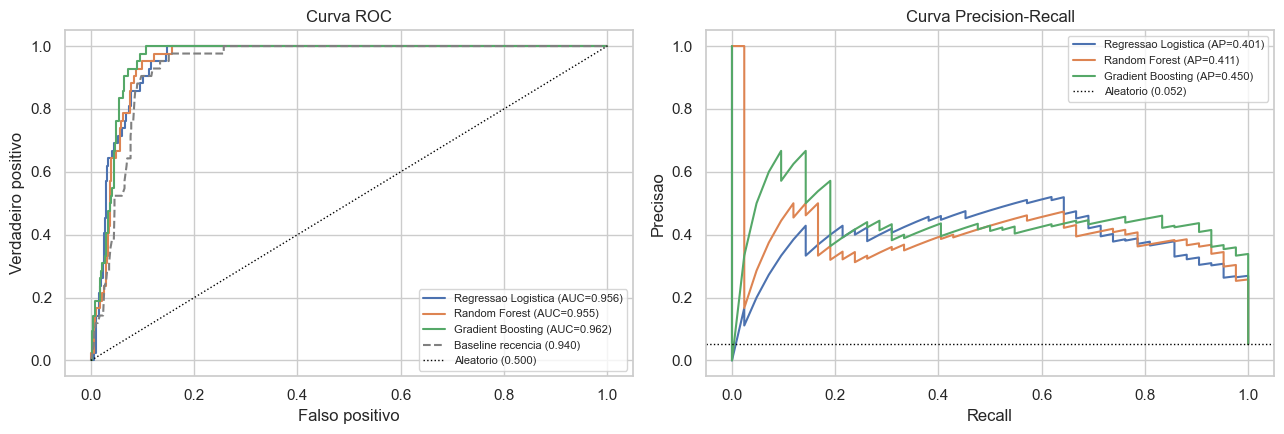

In [7]:
prob_melhor = resultados[melhor_nome]['prob']

# Limiar otimo por F1, em vez do 0.5 padrao
precisoes, recalls, limiares = precision_recall_curve(y_te, prob_melhor)
f1s = 2 * precisoes * recalls / (precisoes + recalls + 1e-12)
idx = int(np.nanargmax(f1s[:-1]))
limiar_otimo = limiares[idx]

pred_05 = (prob_melhor >= 0.5).astype(int)
pred_otimo = (prob_melhor >= limiar_otimo).astype(int)

print(f'MODELO: {melhor_nome}')
print('=' * 66)
print(f'AUC-ROC = {roc_auc_score(y_te, prob_melhor):.4f}   '
      f'(baseline so recencia: {auc_baseline:.4f})')
print(f'AP      = {average_precision_score(y_te, prob_melhor):.4f}   '
      f'(aleatorio: {ap_aleatorio:.4f})')

print(f'\n{"":<12}{"limiar 0.50":>16}{"limiar otimo":>16}')
print('-' * 44)
for rotulo, fn in [('Precisao', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    print(f'{rotulo:<12}{fn(y_te, pred_05, zero_division=0):>16.3f}'
          f'{fn(y_te, pred_otimo, zero_division=0):>16.3f}')
print(f'{"Limiar":<12}{0.50:>16.3f}{limiar_otimo:>16.3f}')

print(f'\nMATRIZ DE CONFUSAO (limiar otimo = {limiar_otimo:.3f})')
cm = confusion_matrix(y_te, pred_otimo)
print(pd.DataFrame(cm, index=['real: nao', 'real: sim'],
                   columns=['prev: nao', 'prev: sim']).to_string())

print(f'\n{classification_report(y_te, pred_otimo, target_names=["nao comprou", "comprou"], zero_division=0)}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    axes[0].plot(fpr, tpr, label=f'{nome} (AUC={res["AUC"]:.3f})')
    p, r, _ = precision_recall_curve(y_te, res['prob'])
    axes[1].plot(r, p, label=f'{nome} (AP={res["AP"]:.3f})')

fpr_b, tpr_b, _ = roc_curve(y_te, score_baseline)
axes[0].plot(fpr_b, tpr_b, '--', c='gray', label=f'Baseline recencia ({auc_baseline:.3f})')
axes[0].plot([0, 1], [0, 1], ':', c='black', lw=1, label='Aleatorio (0.500)')
axes[0].set_xlabel('Falso positivo'); axes[0].set_ylabel('Verdadeiro positivo')
axes[0].set_title('Curva ROC'); axes[0].legend(fontsize=8)

axes[1].axhline(ap_aleatorio, ls=':', c='black', lw=1, label=f'Aleatorio ({ap_aleatorio:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisao')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Explicação do bloco**

- `precision_recall_curve` devolve precisão e recall para **todos** os limiares possíveis.
  Note que `precisoes` e `recalls` têm um elemento a mais que `limiares` — por isso o
  `f1s[:-1]` ao procurar o máximo, descartando o ponto final que não corresponde a limiar
  nenhum. Ignorar esse detalhe causa um `IndexError` ou, pior, seleciona o limiar errado.
- `2 * p * r / (p + r + 1e-12)` — F1 é a média harmônica de precisão e recall. O
  `1e-12` evita divisão por zero quando ambas são zero.
- `np.nanargmax` em vez de `argmax` — protege contra `NaN` que pode surgir em limiares
  extremos onde não há predições positivas.
- **A tabela comparando os dois limiares é o ponto principal desta seção.** Com classe
  desbalanceada, o limiar 0,5 costuma produzir recall baixíssimo: o modelo raramente
  atribui probabilidade acima de 0,5 a uma classe que representa uma fração pequena da
  base. Baixar o limiar aumenta o recall e reduz a precisão. Qual das duas vale mais é
  decisão de negócio, e a tabela existe para tornar essa troca explícita em vez de
  deixá-la escondida num padrão de biblioteca.
- `zero_division=0` — define o comportamento quando não há predições positivas, evitando
  um warning e um `NaN` que contaminariam a tabela.
- A matriz de confusão é impressa como `DataFrame` com rótulos em português porque o array
  cru do sklearn é fácil de ler ao contrário (a convenção é linhas = real, colunas =
  previsto, e trocar os dois inverte a leitura de precisão e recall).
- **Os dois gráficos mostram a mesma informação de dois ângulos.** A ROC parece sempre
  otimista com classe desbalanceada, porque o eixo de falso positivo é normalizado pelos
  negativos, que são maioria. A curva precision-recall não tem esse problema: a linha
  tracejada do aleatório fica na taxa de positivos, e a distância da curva até ela é o
  ganho real. Plotar o baseline de recência junto na ROC responde a pergunta que importa —
  o modelo supera a heurística trivial?

## 9. Importância das features

Duas leituras complementares:

- **Importância do modelo de árvore** — quanto cada variável contribuiu para reduzir a
  impureza nas divisões. Mede *uso*, não direção: não diz se a variável empurra para
  cima ou para baixo.
- **Coeficientes da regressão logística** — dão sinal e magnitude, com as features
  padronizadas para que sejam comparáveis entre si.

**Cuidado com a leitura:** features correlacionadas dividem importância entre si. Se
`Recency` e `RazaoRecenciaIntervalo` são correlacionadas, o modelo pode distribuir o
crédito arbitrariamente entre as duas, e a ausência de uma no topo não significa que ela
seja irrelevante.

IMPORTANCIA DAS FEATURES
                        importancia_arvore  coef_logistica  corr_spearman
RazaoRecenciaIntervalo               0.520          -3.078         -0.348
Tenure                               0.108           0.633         -0.054
GastoRecente90d                      0.079           0.572          0.475
IntervaloMedio                       0.064          -0.755         -0.184
TendenciaGasto                       0.051          -0.224          0.108
Recency                              0.042          -4.892         -0.342
ItensPorPedido                       0.036           0.467          0.025
TaxaDevolucao                        0.031           0.357          0.103
TicketMedio                          0.029          -0.251          0.065
Monetary                             0.018          -1.029          0.209
DesvioTicket                         0.017           0.721          0.219
Frequency                            0.005           0.234          0.240


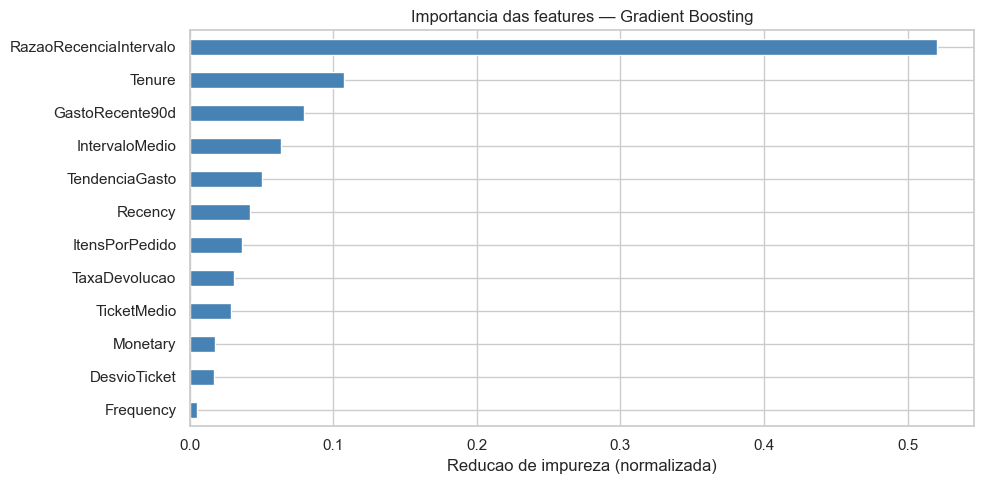


Leitura dos sinais na logistica (features padronizadas):
  Recency                    coef= -4.892  -> REDUZ a chance de recompra
  RazaoRecenciaIntervalo     coef= -3.078  -> REDUZ a chance de recompra
  Monetary                   coef= -1.029  -> REDUZ a chance de recompra
  IntervaloMedio             coef= -0.755  -> REDUZ a chance de recompra
  DesvioTicket               coef=  0.721  -> AUMENTA a chance de recompra


In [8]:
modelo_arvore = modelos['Gradient Boosting']
importancias = pd.Series(modelo_arvore.feature_importances_,
                         index=COLUNAS_FEATURES).sort_values(ascending=False)

logistica = modelos['Regressao Logistica']
coefs = pd.Series(logistica.named_steps['logisticregression'].coef_[0],
                  index=COLUNAS_FEATURES)

comparacao = pd.DataFrame({
    'importancia_arvore': importancias,
    'coef_logistica': coefs,
    'corr_spearman': corr,
}).sort_values('importancia_arvore', ascending=False)

print('IMPORTANCIA DAS FEATURES')
print(comparacao.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importancias.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Importancia das features — {melhor_nome if "Boosting" in melhor_nome else "Gradient Boosting"}')
ax.set_xlabel('Reducao de impureza (normalizada)')
plt.tight_layout(); plt.show()

print('\nLeitura dos sinais na logistica (features padronizadas):')
for nome_f in coefs.abs().sort_values(ascending=False).head(5).index:
    direcao = 'AUMENTA' if coefs[nome_f] > 0 else 'REDUZ'
    print(f'  {nome_f:<26} coef={coefs[nome_f]:>7.3f}  -> {direcao} a chance de recompra')

**Explicação do bloco**

- `modelo_arvore.feature_importances_` — array na mesma ordem das colunas de treino.
  Envolvê-lo numa `pd.Series` com `index=COLUNAS_FEATURES` é o que liga cada número ao
  nome certo; confiar na ordem mentalmente é uma fonte clássica de erro silencioso.
- `logistica.named_steps['logisticregression']` — acessa o estimador final dentro do
  pipeline. `make_pipeline` nomeia os passos automaticamente pela classe em minúsculas,
  daí o nome. `.coef_[0]` pega a primeira (e única) linha, porque é classificação binária.
- **Os coeficientes só são comparáveis entre si porque as features foram padronizadas**
  dentro do pipeline. Em escala original, um coeficiente pequeno pode acompanhar uma
  variável de magnitude enorme e ter efeito grande — e a comparação direta seria enganosa.
- A tabela junta três visões: importância da árvore (uso), coeficiente (direção e
  magnitude linear) e correlação de Spearman (relação monotônica bruta com o alvo).
  Quando as três concordam, a conclusão é sólida. Quando discordam, normalmente há
  interação ou não linearidade que só o modelo de árvore captura — e é aí que vale
  investigar.
- O laço final traduz o sinal do coeficiente em linguagem direta. Um coeficiente negativo
  em `Recency` significa que recência maior reduz a chance de recompra, que é exatamente
  o esperado — e serve como verificação de sanidade: se o sinal viesse invertido, haveria
  erro na construção do alvo ou das features.

## 10. Limitações

1. **O modelo só fala sobre quem tem passado.** Clientes que aparecem pela primeira vez na
   janela do alvo foram excluídos por construção (seção 3). Aquisição exige outra
   abordagem.

2. **Uma única janela temporal.** Treinar sobre um único par observação/alvo captura o
   comportamento de um período específico — que pode ter sido atípico (sazonalidade,
   campanha, evento externo). O tratamento correto é gerar **várias safras**, deslizando a
   data de corte no tempo e empilhando os exemplos, o que aumenta o volume e dilui o efeito
   de um período incomum.

3. **A janela de 90 dias é uma escolha.** Precisa ser calibrada contra o ciclo de recompra
   real do negócio. O aviso automático da seção 4 checa apenas se a proporção de positivos
   é razoável, o que é condição necessária mas não suficiente.

4. **Correlação não é causa.** O modelo identifica quem *vai* comprar, não quem *pode ser
   convencido a* comprar. São coisas diferentes: agir sobre quem já compraria de qualquer
   forma gasta verba sem gerar incremento. Responder à pergunta causal exige modelagem de
   *uplift* e, idealmente, um grupo de controle aleatorizado.

5. **O modelo envelhece.** Comportamento de compra muda, e a relação aprendida entre
   features e alvo se degrada. Exige reavaliação periódica contra o que de fato aconteceu.

6. **Sem variáveis externas.** Preço, campanha, estoque, concorrência e sazonalidade não
   entram. Parte do erro residual vem daí, não de falha do algoritmo.

7. **Base sintética.** Como registrado na seção 1, os dados reais não foram fornecidos. As
   métricas desta execução descrevem dados gerados — em dados reais, o desempenho
   costuma ser mais baixo, porque o mundo tem mais ruído do que um gerador.

## 11. Código completo

Pipeline consolidado e autossuficiente, do carregamento à avaliação.

In [9]:
"""PREVISAO DE RECOMPRA — pipeline supervisionado com separacao temporal."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score,
                             precision_score, f1_score, confusion_matrix,
                             precision_recall_curve)

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
SEED, DIAS_ALVO = 42, 90


def gerar_base_sintetica(n_clientes=3000, seed=SEED):
    """ASSUMPTION: base real nao disponivel — substitua por pd.read_csv(...).

    Cada cliente tem um ciclo de recompra proprio (intervalo) e uma distancia ate a
    ultima compra. Os pedidos sao construidos de tras para frente a partir dela.
    """
    rng = np.random.default_rng(seed)
    fim_janela = pd.Timestamp('2011-12-09')
    linhas, invoice = [], 500000
    for cliente in range(1, n_clientes + 1):
        dias_desde_ultima = int(rng.integers(0, 730))
        n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))
        intervalo = int(rng.integers(10, 120))
        for p in range(n_pedidos):
            offset = dias_desde_ultima + p * intervalo
            if offset > 729:
                break
            invoice += 1
            data = fim_janela - pd.Timedelta(days=offset) + pd.Timedelta(hours=int(rng.integers(8, 19)))
            devolucao = rng.random() < 0.04
            for _ in range(int(rng.integers(1, 6))):
                qtd = -int(rng.integers(1, 5)) if devolucao else int(rng.integers(1, 15))
                preco = round(float(rng.lognormal(mean=2.0, sigma=0.9)), 2)
                linhas.append((cliente, str(invoice), data, qtd, preco))
    df = pd.DataFrame(linhas, columns=['Customer ID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price'])
    df.loc[df.sample(frac=0.018, random_state=1).index, 'Customer ID'] = np.nan
    df.loc[df.sample(frac=0.006, random_state=2).index, 'Price'] = 0.0
    df = pd.concat([df, df.sample(frac=0.01, random_state=3)], ignore_index=True)
    return df.sample(frac=1, random_state=4).reset_index(drop=True)


def preparar_dados(df):
    df = df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price']).copy()
    df = df.drop_duplicates()
    df['Customer ID'] = df['Customer ID'].astype('int64')
    df['LineTotal'] = df['Quantity'] * df['Price']
    df['eh_devolucao'] = df['Quantity'] < 0
    return df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]


def separar_janelas(df, dias_alvo=DIAS_ALVO):
    """A regra que evita o vazamento: features antes do corte, alvo depois."""
    data_corte = df['InvoiceDate'].max().normalize() - pd.Timedelta(days=dias_alvo)
    obs = df[df['InvoiceDate'] <= data_corte].copy()
    alvo_df = df[df['InvoiceDate'] > data_corte].copy()
    assert obs['InvoiceDate'].max() <= data_corte, 'observacao invade a data de corte'
    assert alvo_df['InvoiceDate'].min() > data_corte, 'alvo comeca antes da data de corte'
    return obs, alvo_df, data_corte


def construir_alvo(obs, alvo_df):
    clientes_obs = obs['Customer ID'].unique()
    compradores = set(alvo_df.loc[~alvo_df['eh_devolucao'], 'Customer ID'])
    return pd.Series(np.isin(clientes_obs, list(compradores)).astype(int),
                     index=pd.Index(clientes_obs, name='Customer ID'),
                     name='comprou_90d').sort_index()


def construir_features(obs, data_corte):
    """Todas as features saem EXCLUSIVAMENTE da janela de observacao."""
    compras = obs[~obs['eh_devolucao']]
    g = compras.groupby('Customer ID')
    f = g.agg(Frequency=('Invoice', 'nunique'), UltimaCompra=('InvoiceDate', 'max'),
              PrimeiraCompra=('InvoiceDate', 'min'), n_linhas=('Invoice', 'size'))
    f['Monetary'] = obs.groupby('Customer ID')['LineTotal'].sum()
    f['Recency'] = (data_corte - f['UltimaCompra']).dt.days     # referencia = corte
    f['Tenure'] = (data_corte - f['PrimeiraCompra']).dt.days

    span = (f['UltimaCompra'] - f['PrimeiraCompra']).dt.days
    f['IntervaloMedio'] = np.where(f['Frequency'] > 1,
                                   span / (f['Frequency'] - 1).clip(lower=1),
                                   f['Tenure']).clip(min=1)
    f['RazaoRecenciaIntervalo'] = f['Recency'] / f['IntervaloMedio']

    valor_pedido = compras.groupby(['Customer ID', 'Invoice'])['LineTotal'].sum()
    f['TicketMedio'] = valor_pedido.groupby('Customer ID').mean()
    f['DesvioTicket'] = valor_pedido.groupby('Customer ID').std().fillna(0)
    f['ItensPorPedido'] = f['n_linhas'] / f['Frequency']

    c_rec, c_ant = data_corte - pd.Timedelta(days=90), data_corte - pd.Timedelta(days=180)
    recente = obs[obs['InvoiceDate'] > c_rec].groupby('Customer ID')['LineTotal'].sum()
    anterior = obs[(obs['InvoiceDate'] > c_ant) &
                   (obs['InvoiceDate'] <= c_rec)].groupby('Customer ID')['LineTotal'].sum()
    f['GastoRecente90d'] = recente.reindex(f.index).fillna(0)
    f['TendenciaGasto'] = (f['GastoRecente90d'] + 1) / (anterior.reindex(f.index).fillna(0) + 1)

    devolucoes = obs[obs['eh_devolucao']].groupby('Customer ID').size()
    f['TaxaDevolucao'] = (devolucoes.reindex(f.index).fillna(0) /
                          obs.groupby('Customer ID').size().reindex(f.index))
    return f.drop(columns=['UltimaCompra', 'PrimeiraCompra', 'n_linhas'])


def treinar(X_tr, y_tr, seed=SEED):
    modelos = {
        'Regressao Logistica': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed)),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight='balanced',
            random_state=seed, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05, random_state=seed),
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for nome, m in modelos.items():
        s = cross_val_score(m, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
        m.fit(X_tr, y_tr)
        print(f'{nome:<22} CV AUC = {s.mean():.4f} (+/- {s.std():.4f})')
    return modelos


def avaliar(modelos, X_te, y_te):
    baseline = -X_te['Recency']
    print(f'\nBaseline so recencia: AUC = {roc_auc_score(y_te, baseline):.4f}')
    resultados = {}
    for nome, m in modelos.items():
        prob = m.predict_proba(X_te)[:, 1]
        resultados[nome] = {'AUC': roc_auc_score(y_te, prob),
                            'AP': average_precision_score(y_te, prob), 'prob': prob}
        print(f'{nome:<22} AUC = {resultados[nome]["AUC"]:.4f}   AP = {resultados[nome]["AP"]:.4f}')

    melhor = max(resultados, key=lambda k: resultados[k]['AP'])
    prob = resultados[melhor]['prob']
    p, r, lim = precision_recall_curve(y_te, prob)
    f1s = 2 * p * r / (p + r + 1e-12)
    limiar = lim[int(np.nanargmax(f1s[:-1]))]
    pred = (prob >= limiar).astype(int)

    print(f'\nMelhor: {melhor} | limiar otimo = {limiar:.3f}')
    print(f'  Precisao={precision_score(y_te, pred, zero_division=0):.3f}  '
          f'Recall={recall_score(y_te, pred, zero_division=0):.3f}  '
          f'F1={f1_score(y_te, pred, zero_division=0):.3f}')
    print(pd.DataFrame(confusion_matrix(y_te, pred),
                       index=['real: nao', 'real: sim'],
                       columns=['prev: nao', 'prev: sim']).to_string())
    return resultados, melhor


def executar():
    raw_df = gerar_base_sintetica()      # <-- trocar por pd.read_csv(...) na base real
    raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'])
    df = preparar_dados(raw_df)

    obs, alvo_df, data_corte = separar_janelas(df)
    alvo = construir_alvo(obs, alvo_df)
    features = construir_features(obs, data_corte)
    dados = features.join(alvo, how='inner')

    X, y = dados[features.columns], dados['comprou_90d']
    assert not X.isna().any().any(), 'features com NaN'
    print(f'Corte: {data_corte:%d/%m/%Y} | {X.shape[0]:,} clientes x {X.shape[1]} features '
          f'| {y.mean():.1%} positivos\n')

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                              random_state=SEED, stratify=y)
    modelos = treinar(X_tr, y_tr)
    resultados, melhor = avaliar(modelos, X_te, y_te)

    imp = pd.Series(modelos['Gradient Boosting'].feature_importances_,
                    index=list(features.columns)).sort_values(ascending=False)
    print('\nTop 5 features:')
    print(imp.head(5).round(4).to_string())
    return modelos, resultados, X, y


if __name__ == '__main__':
    modelos_final, resultados_final, X_final, y_final = executar()

Corte: 10/09/2011 | 2,704 clientes x 12 features | 5.2% positivos

Regressao Logistica    CV AUC = 0.9662 (+/- 0.0072)
Random Forest          CV AUC = 0.9642 (+/- 0.0058)
Gradient Boosting      CV AUC = 0.9602 (+/- 0.0056)

Baseline so recencia: AUC = 0.9403
Regressao Logistica    AUC = 0.9556   AP = 0.4009
Random Forest          AUC = 0.9551   AP = 0.4107
Gradient Boosting      AUC = 0.9622   AP = 0.4503

Melhor: Gradient Boosting | limiar otimo = 0.169
  Precisao=0.461  Recall=0.833  F1=0.593
           prev: nao  prev: sim
real: nao        729         41
real: sim          7         35

Top 5 features:
RazaoRecenciaIntervalo   0.520
Tenure                   0.108
GastoRecente90d          0.079
IntervaloMedio           0.064
TendenciaGasto           0.051


**Explicação do bloco consolidado**

A estrutura reflete a ordem em que os erros acontecem — cada função isola um ponto de
falha conhecido:

1. **`separar_janelas`** — a primeira coisa a rodar, e a que carrega os dois `assert`.
   Retornar `data_corte` junto com as fatias obriga as etapas seguintes a usarem a mesma
   referência, em vez de recalculá-la.
2. **`construir_alvo`** — o alvo sai da janela do alvo, filtrando devoluções, e é indexado
   pelos clientes da observação.
3. **`construir_features`** — recebe `data_corte` como argumento **obrigatório**. É a
   decisão de design mais importante do arquivo: a função não tem como calcular a recência
   contra o fim da base, porque não conhece o fim da base. O vazamento fica impossível por
   construção, não por disciplina de quem escreve.
4. **`treinar`** — os três modelos com validação cruzada estratificada.
5. **`avaliar`** — baseline primeiro, depois os modelos, depois o limiar ótimo. A ordem é
   a da argumentação: uma métrica de modelo só significa algo depois de existir a
   referência contra a qual compará-la.
6. **`executar`** — orquestra e é o único ponto com `print` de relatório.

Para produção, o que precisa ser salvo é o modelo escolhido **e** a função
`construir_features`: aplicar o modelo a features construídas de outra forma é a maneira
mais comum de um modelo que ia bem em teste falhar silenciosamente depois.